# Cat/dog geometry dynamics across deep CNN blocks

Four ImageNet-pretrained networks: ResNet-18, ResNet-152, ConvNeXt-Tiny, ConvNeXt-Base. We sample after **each residual block**, plus stems and downsampling transitions, using the same 200 images and one preprocessing transform. All figures are descriptive; a CKA dip is a change in representational similarity, not proof of a phase transition. The probe and PR are auxiliary readouts.


In [ ]:
import torch, torchvision, numpy as np, pandas as pd, matplotlib.pyplot as plt
from torchvision import models
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from PIL import Image
from io import BytesIO
from pathlib import Path
import zipfile, urllib.request, hashlib, gc

SEED=42; N_PER_CLASS=100; BATCH_SIZE=16; PROBE_SPLITS=5
np.random.seed(SEED); torch.manual_seed(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Run in order, releasing each network before loading the next.
MODEL_SPECS=[
 ('ResNet-18',models.resnet18,models.ResNet18_Weights.IMAGENET1K_V1),
 ('ResNet-152',models.resnet152,models.ResNet152_Weights.IMAGENET1K_V2),
 ('ConvNeXt-Tiny',models.convnext_tiny,models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1),
 ('ConvNeXt-Base',models.convnext_base,models.ConvNeXt_Base_Weights.IMAGENET1K_V1),
]
print('torch',torch.__version__,'torchvision',torchvision.__version__,'device',device)


torch 2.11.0+cu128 torchvision 0.26.0+cu128 device cuda


In [ ]:
# 1. Same 100 cats and 100 dogs for every model and every stage.
# Zenodo Cats and Dogs sample: https://zenodo.org/records/5226945
# All listed ImageNet weights use the same resize/crop/normalization recipe.
transform = MODEL_SPECS[0][2].transforms()
# Use this single transform for every architecture and weight condition.
archive = Path('cats_dogs_light.zip')
if not archive.exists():
    urllib.request.urlretrieve('https://zenodo.org/records/5226945/files/cats_dogs_light.zip?download=1', archive)
expected_md5 = '5e014163374c3bf7069c923de2d619c8'
actual_md5 = hashlib.md5(archive.read_bytes()).hexdigest()
assert actual_md5 == expected_md5, f'Download checksum mismatch: {actual_md5}'

class ZipCatsDogs(Dataset):
    def __init__(self, path, transform):
        self.path, self.transform = path, transform
        with zipfile.ZipFile(path) as zf:
            self.names = [name for name in zf.namelist()
                          if '/test/' in name.lower() and name.lower().endswith(('.jpg', '.jpeg', '.png'))
                          and Path(name).name.lower().startswith(('cat.', 'dog.'))]
        self.targets = [3 if Path(name).name.lower().startswith('cat.') else 5 for name in self.names]
        assert self.names, 'No labeled cat/dog test images found; inspect archive paths.'
    def __len__(self): return len(self.names)
    def __getitem__(self, index):
        with zipfile.ZipFile(self.path) as zf:
            image = Image.open(BytesIO(zf.read(self.names[index]))).convert('RGB')
        return self.transform(image), self.targets[index]

raw = ZipCatsDogs(archive, transform)
y_all = np.asarray(raw.targets)
rng = np.random.default_rng(SEED)
assert all((y_all == cls).sum() >= N_PER_CLASS for cls in (3, 5)), 'Reduce N_PER_CLASS.'
indices = np.concatenate([rng.choice(np.flatnonzero(y_all == cls), N_PER_CLASS, replace=False) for cls in (3, 5)])
indices = rng.permutation(indices).tolist()
selected = Subset(raw, indices)
loader = DataLoader(selected, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'))
labels = np.asarray([y_all[i] for i in indices])
print(f'{len(selected)} images: {(labels == 3).sum()} cats, {(labels == 5).sum()} dogs')


200 images: 100 cats, 100 dogs


In [ ]:
# The hook list follows actual module execution order. Stage boundaries are explicit.
def observed_modules(name,model):
    pairs=[]; boundaries=[]
    if name.startswith('ResNet'):
        pairs.append(('stem',model.maxpool)); boundaries.append('stem')
        for i in range(1,5):
            for j,block in enumerate(getattr(model,f'layer{i}')):
                label=f's{i}.b{j+1}'
                pairs.append((label,block))
                if j==0: boundaries.append(label)
    else:
        for idx,module in enumerate(model.features):
            if idx==0:
                pairs.append(('stem',module)); boundaries.append('stem')
            elif idx%2==0:
                label=f'down{idx//2}'
                pairs.append((label,module)); boundaries.append(label)
            else:
                stage=(idx+1)//2
                for j,block in enumerate(module):
                    label=f's{stage}.b{j+1}'
                    pairs.append((label,block))
                    if j==0: boundaries.append(label)
    return pairs,boundaries

def extract_blocks(model,loader,pairs):
    model=model.to(device).eval()
    record={key:[] for key,_ in pairs}; cache={}; hooks=[]
    for key,module in pairs:
        def grab(m,inp,out,key=key):
            h=out.detach()
            if h.ndim==4: h=h.mean((-2,-1))
            cache[key]=h.flatten(1).cpu()
        hooks.append(module.register_forward_hook(grab))
    try:
        with torch.inference_mode():
            for images,_ in loader:
                _=model(images.to(device))
                for key in record: record[key].append(cache.pop(key))
    finally:
        for h in hooks: h.remove()
        model.cpu()
        if device.type=='cuda': torch.cuda.empty_cache()
    return {key:torch.cat(parts).numpy() for key,parts in record.items()}


In [ ]:
# Run after the notebook's setup, dataset, and hook-function cells.
# The saved rows preserve the selected image order across all nine stages.
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
pairs, _ = observed_modules('ResNet-18', model)
feats = extract_blocks(model, loader, pairs)
del model
stage_names = np.array(list(feats))
names = np.array([raw.names[i] for i in indices])
assert len(stage_names) == 9 and len(names) == len(labels) == 200
payload = {'stages': stage_names, 'labels': labels, 'archive_paths': names,
           'selected_indices': np.array(indices)}
for j, stage in enumerate(stage_names):
    payload[f'features_{j}'] = feats[stage].astype(np.float32)
out = 'resnet18_per_image_vectors.npz'
np.savez_compressed(out, **payload)
print('Saved', out, 'stages:', list(stage_names),
      'shapes:', [feats[s].shape for s in stage_names],
      'label counts:', np.unique(labels, return_counts=True))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


Saved resnet18_per_image_vectors.npz stages: [np.str_('stem'), np.str_('s1.b1'), np.str_('s1.b2'), np.str_('s2.b1'), np.str_('s2.b2'), np.str_('s3.b1'), np.str_('s3.b2'), np.str_('s4.b1'), np.str_('s4.b2')] shapes: [(200, 64), (200, 64), (200, 64), (200, 128), (200, 128), (200, 256), (200, 256), (200, 512), (200, 512)] label counts: (array([3, 5]), array([100, 100]))


In [ ]:
from google.colab import files
files.download('resnet18_per_image_vectors.npz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Run after setup, dataset, and hook-function cells in this notebook.
# The sample order and preprocessing are identical to the ResNet-18 export.
model152 = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)
pairs152, _ = observed_modules('ResNet-152', model152)
feats152 = extract_blocks(model152, loader, pairs152)
del model152
stages152 = np.array(list(feats152))
assert len(stages152) == 51 and len(labels) == 200
payload152 = {
    'stages': stages152,
    'labels': labels,
    'archive_paths': np.array([raw.names[i] for i in indices]),
    'selected_indices': np.array(indices),
}
for j, stage in enumerate(stages152):
    payload152[f'features_{j}'] = feats152[stage].astype(np.float32)
out152 = 'resnet152_per_image_vectors.npz'
np.savez_compressed(out152, **payload152)
print('Saved', out152, 'points:', len(stages152),
      'first/last:', stages152[0], stages152[-1],
      'feature widths:', sorted(set(x.shape[1] for x in feats152.values())),
      'label counts:', np.unique(labels, return_counts=True))
del feats152, payload152
gc.collect()


Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:02<00:00, 112MB/s]


Saved resnet152_per_image_vectors.npz points: 51 first/last: stem s4.b3 feature widths: [64, 256, 512, 1024, 2048] label counts: (array([3, 5]), array([100, 100]))


10

In [ ]:
from google.colab import files
files.download('resnet152_per_image_vectors.npz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Same selected 200 images and transform as the ResNet experiments.
model_tiny = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
pairs_tiny, _ = observed_modules('ConvNeXt-Tiny', model_tiny)
feats_tiny = extract_blocks(model_tiny, loader, pairs_tiny)
del model_tiny
stages_tiny = np.array(list(feats_tiny))
assert len(stages_tiny) == 22 and len(labels) == 200
payload_tiny = {
    'stages': stages_tiny,
    'labels': labels,
    'archive_paths': np.array([raw.names[i] for i in indices]),
    'selected_indices': np.array(indices),
}
for j, stage in enumerate(stages_tiny):
    payload_tiny[f'features_{j}'] = feats_tiny[stage].astype(np.float32)
out_tiny = 'convnext_tiny_per_image_vectors.npz'
np.savez_compressed(out_tiny, **payload_tiny)
print('Saved', out_tiny, 'points:', len(stages_tiny),
      'stages:', list(stages_tiny),
      'feature widths:', sorted(set(x.shape[1] for x in feats_tiny.values())),
      'label counts:', np.unique(labels, return_counts=True))
del feats_tiny, payload_tiny
gc.collect()


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 151MB/s]


Saved convnext_tiny_per_image_vectors.npz points: 22 stages: [np.str_('stem'), np.str_('s1.b1'), np.str_('s1.b2'), np.str_('s1.b3'), np.str_('down1'), np.str_('s2.b1'), np.str_('s2.b2'), np.str_('s2.b3'), np.str_('down2'), np.str_('s3.b1'), np.str_('s3.b2'), np.str_('s3.b3'), np.str_('s3.b4'), np.str_('s3.b5'), np.str_('s3.b6'), np.str_('s3.b7'), np.str_('s3.b8'), np.str_('s3.b9'), np.str_('down3'), np.str_('s4.b1'), np.str_('s4.b2'), np.str_('s4.b3')] feature widths: [96, 192, 384, 768] label counts: (array([3, 5]), array([100, 100]))


0

In [ ]:
from google.colab import files
files.download('convnext_tiny_per_image_vectors.npz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Same selected 200 images and transform as the ResNet experiments.
model_base = models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
pairs_base, _ = observed_modules('ConvNeXt-Base', model_base)
feats_base = extract_blocks(model_base, loader, pairs_base)
del model_base
stages_base = np.array(list(feats_base))
assert len(stages_base) == 40 and len(labels) == 200
payload_base = {
    'stages': stages_base,
    'labels': labels,
    'archive_paths': np.array([raw.names[i] for i in indices]),
    'selected_indices': np.array(indices),
}
for j, stage in enumerate(stages_base):
    payload_base[f'features_{j}'] = feats_base[stage].astype(np.float32)
out_base = 'convnext_base_per_image_vectors.npz'
np.savez_compressed(out_base, **payload_base)
print('Saved', out_base, 'points:', len(stages_base),
      'stages:', list(stages_base),
      'feature widths:', sorted(set(x.shape[1] for x in feats_base.values())),
      'label counts:', np.unique(labels, return_counts=True))
del feats_base, payload_base
gc.collect()


Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:05<00:00, 64.8MB/s]


Saved convnext_base_per_image_vectors.npz points: 40 stages: [np.str_('stem'), np.str_('s1.b1'), np.str_('s1.b2'), np.str_('s1.b3'), np.str_('down1'), np.str_('s2.b1'), np.str_('s2.b2'), np.str_('s2.b3'), np.str_('down2'), np.str_('s3.b1'), np.str_('s3.b2'), np.str_('s3.b3'), np.str_('s3.b4'), np.str_('s3.b5'), np.str_('s3.b6'), np.str_('s3.b7'), np.str_('s3.b8'), np.str_('s3.b9'), np.str_('s3.b10'), np.str_('s3.b11'), np.str_('s3.b12'), np.str_('s3.b13'), np.str_('s3.b14'), np.str_('s3.b15'), np.str_('s3.b16'), np.str_('s3.b17'), np.str_('s3.b18'), np.str_('s3.b19'), np.str_('s3.b20'), np.str_('s3.b21'), np.str_('s3.b22'), np.str_('s3.b23'), np.str_('s3.b24'), np.str_('s3.b25'), np.str_('s3.b26'), np.str_('s3.b27'), np.str_('down3'), np.str_('s4.b1'), np.str_('s4.b2'), np.str_('s4.b3')] feature widths: [128, 256, 512, 1024] label counts: (array([3, 5]), array([100, 100]))


10

In [ ]:
from google.colab import files
files.download('convnext_base_per_image_vectors.npz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Metrics: cosine pairwise geometry on per-image unit vectors; raw Fisher ratio.
# Squared Euclidean distance on unit vectors is 2 * cosine distance, so these are not independent measurements.
def representation_stats(x,y):
    x=np.asarray(x,dtype=np.float64)
    z=x/np.maximum(np.linalg.norm(x,axis=1,keepdims=True),1e-12)
    cat,dog=z[y==3],z[y==5]
    def within_cos(q):
        n=len(q)
        return 1-(np.sum(q.sum(axis=0)**2)-n)/(n*(n-1))
    dc=(within_cos(cat)+within_cos(dog))/2
    db=1-cat.mean(axis=0)@dog.mean(axis=0)
    # For mean *Euclidean* pairwise distances, use a 200x200 distance matrix.
    sim=np.clip(z@z.T,-1,1)
    dist=np.sqrt(np.maximum(0,2-2*sim))
    ci=np.flatnonzero(y==3); di=np.flatnonzero(y==5)
    wc=dist[np.ix_(ci,ci)][np.triu_indices(len(ci),1)].mean()
    wd=dist[np.ix_(di,di)][np.triu_indices(len(di),1)].mean()
    edw=(wc+wd)/2; edb=dist[np.ix_(ci,di)].mean()
    # Fisher on raw, globally pooled features, invariant to a global scalar only.
    a,b=x[y==3],x[y==5]; ma,mb=a.mean(0),b.mean(0)
    var=np.mean(np.sum((a-ma)**2,axis=1))+np.mean(np.sum((b-mb)**2,axis=1))
    fisher=np.sum((ma-mb)**2)/max(var,1e-20)
    centered=z-z.mean(0)
    eigen=np.maximum(np.linalg.eigvalsh(centered@centered.T),0)
    pr=eigen.sum()**2/max(np.square(eigen).sum(),1e-20)
    return {'d_within_cos':dc,'d_between_cos':db,'S':db/dc,
            'd_within_euclid_unit':edw,'d_between_euclid_unit':edb,
            'Fisher_raw':fisher,'PR':pr,'mean_raw_norm':np.linalg.norm(x,axis=1).mean()}

def centered_gram(x):
    x=np.asarray(x,dtype=np.float64)
    x=x-x.mean(0,keepdims=True)
    gram=x@x.T
    return gram/np.maximum(np.linalg.norm(gram,'fro'),1e-20)

def linear_cka(x1,x2):
    return float(np.sum(centered_gram(x1)*centered_gram(x2)))

def probe_scores(x,y,splits):
    acc=[]
    for train,test in splits:
        p=make_pipeline(Normalizer(),StandardScaler(),LogisticRegression(C=1,max_iter=2000,solver='liblinear',random_state=SEED))
        p.fit(x[train],y[train]); acc.append(accuracy_score(y[test],p.predict(x[test])))
    return float(np.mean(acc)),float(np.std(acc,ddof=1))

def relative_geometry_trajectory(feats,y):
    # Shared coordinates: each sample's similarities to the SAME ordered set of images.
    # Center and unit-normalize each sample Gram matrix before pooling all class centroids in a single PCA.
    points=[]
    for x in feats.values():
        z=x.astype(np.float64); z/=np.maximum(np.linalg.norm(z,axis=1,keepdims=True),1e-12)
        k=centered_gram(z)
        points.extend([k[y==3].mean(0),k[y==5].mean(0)])
    return PCA(n_components=2).fit_transform(np.asarray(points))


In [ ]:
splits=list(StratifiedShuffleSplit(n_splits=PROBE_SPLITS,test_size=.30,random_state=SEED).split(np.zeros(len(labels)),labels))
all_rows=[]; trajectories={}; model_boundaries={}; model_stages={}
for name,constructor,weights in MODEL_SPECS:
    print('Starting',name,flush=True)
    model=constructor(weights=weights)
    pairs,boundaries=observed_modules(name,model)
    feats=extract_blocks(model,loader,pairs)
    del model; gc.collect()
    model_boundaries[name]=boundaries
    model_stages[name]=list(feats)
    trajectories[name]=relative_geometry_trajectory(feats,labels)
    previous=None
    for depth,(stage,x) in enumerate(feats.items()):
        stats=representation_stats(x,labels)
        mean,sd=probe_scores(x,labels,splits)
        all_rows.append({'model':name,'depth':depth,'stage':stage,'boundary':stage in boundaries,
                         'CKA_prev':np.nan if previous is None else linear_cka(previous,x),
                         'probe_mean':mean,'probe_sd':sd,**stats})
        previous=x
    del feats,previous
    print('Finished',name,'measurement points',len(pairs),flush=True)
results=pd.DataFrame(all_rows)
display(results.groupby('model',sort=False).agg(points=('stage','size'),
    min_adjacent_CKA=('CKA_prev','min'),S_first=('S','first'),S_last=('S','last'),
    probe_first=('probe_mean','first'),probe_last=('probe_mean','last')).round(3))


Starting ResNet-18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


Finished ResNet-18 measurement points 9
Starting ResNet-152
Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 180MB/s]


Finished ResNet-152 measurement points 51
Starting ConvNeXt-Tiny
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 168MB/s] 


Finished ConvNeXt-Tiny measurement points 22
Starting ConvNeXt-Base
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:03<00:00, 115MB/s]


Finished ConvNeXt-Base measurement points 40


,points,min_adjacent_CKA,S_first,S_last,probe_first,probe_last
model,,,,,,
ResNet-18,9,0.761,1.016,1.342,0.577,0.997
ResNet-152,51,0.396,1.004,1.305,0.613,1.000
ConvNeXt-Tiny,22,0.118,1.033,1.341,0.543,1.000
ConvNeXt-Base,40,0.088,1.030,1.347,0.530,1.000


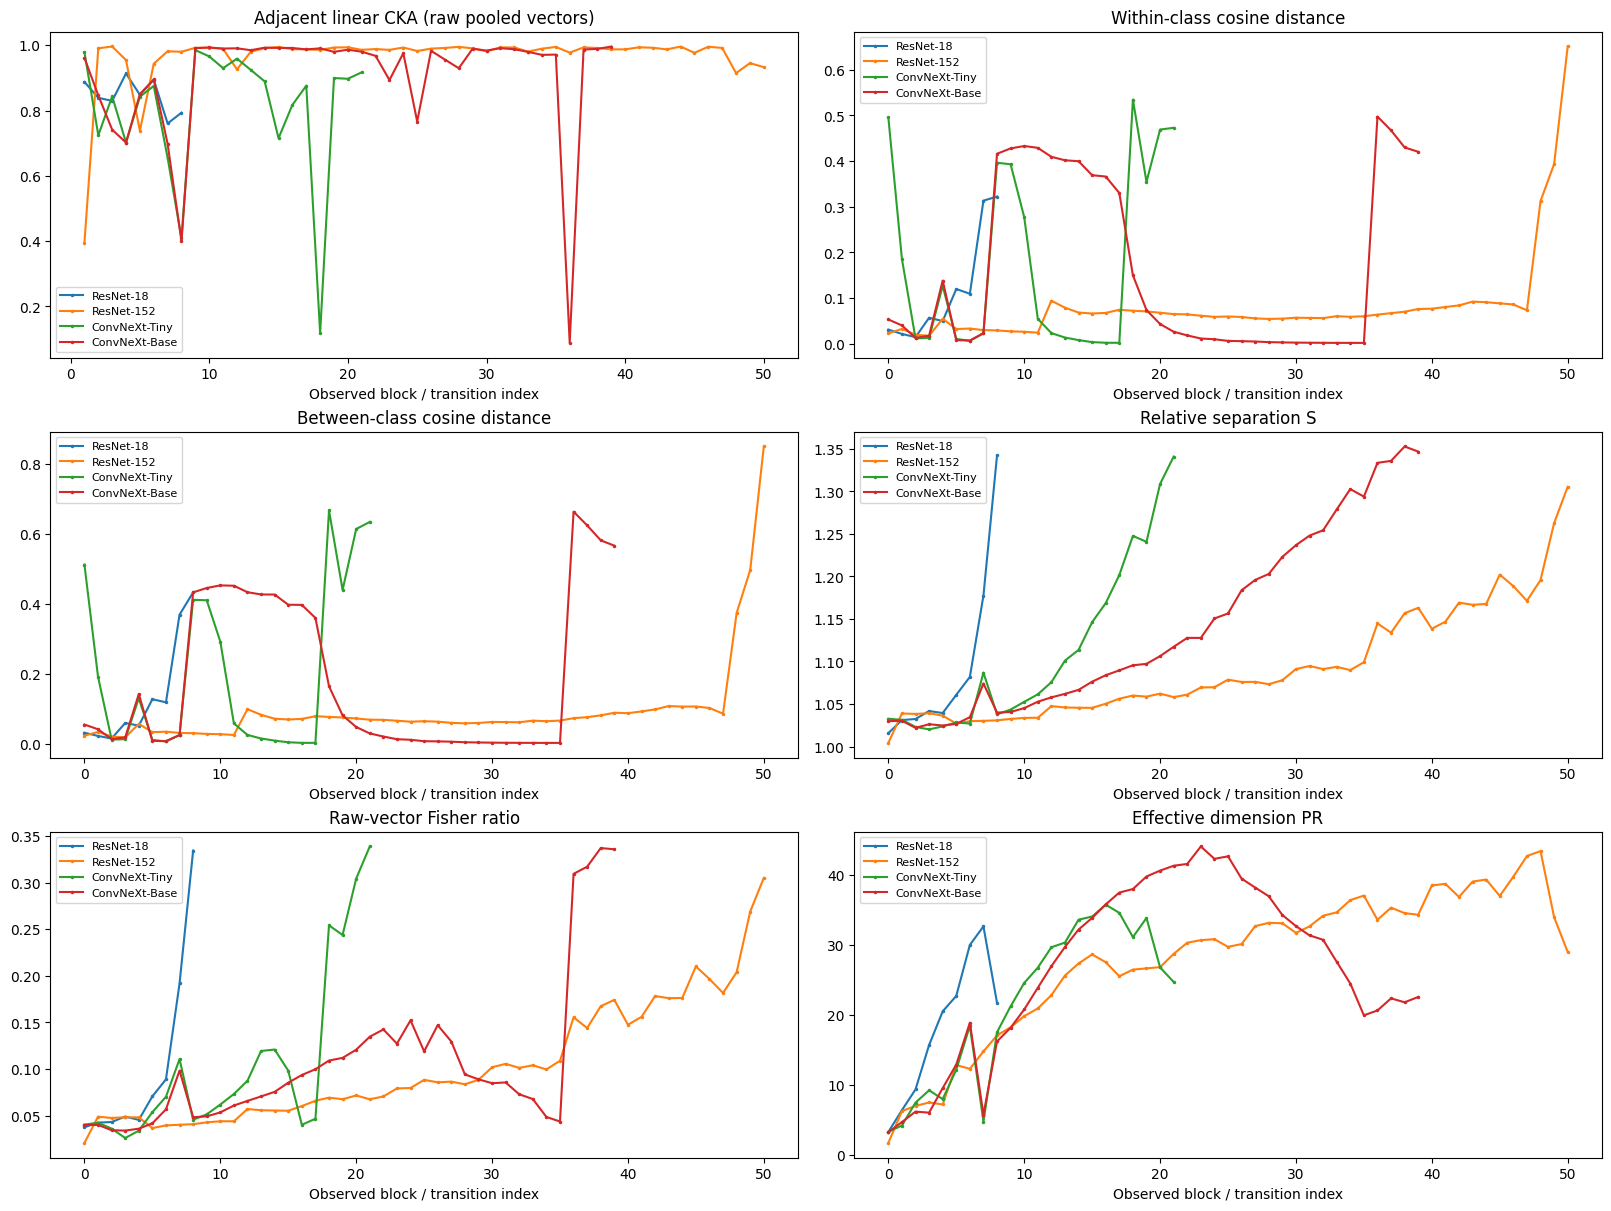

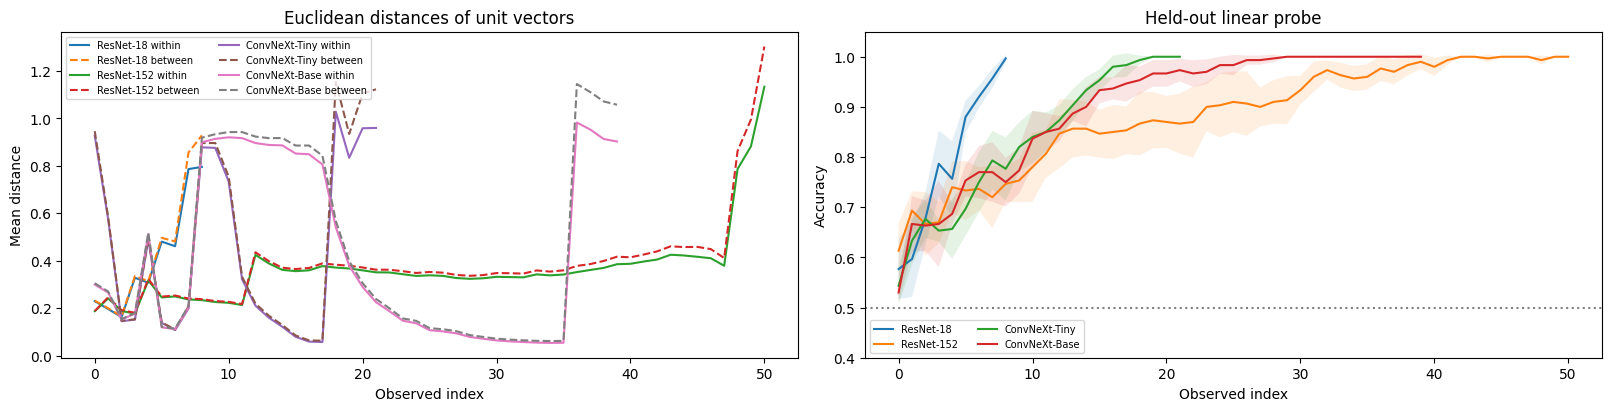

In [ ]:
fig,axs=plt.subplots(3,2,figsize=(16,12),constrained_layout=True)
measures=[('CKA_prev','Adjacent linear CKA (raw pooled vectors)'),
          ('d_within_cos','Within-class cosine distance'),('d_between_cos','Between-class cosine distance'),
          ('S','Relative separation S'),('Fisher_raw','Raw-vector Fisher ratio'),('PR','Effective dimension PR')]
for ax,(field,title) in zip(axs.flat,measures):
    for name,g in results.groupby('model',sort=False):
        ax.plot(g.depth,g[field],marker='.',markersize=3,label=name)
    ax.set(title=title,xlabel='Observed block / transition index')
    ax.legend(fontsize=8)
plt.show()

fig,axs=plt.subplots(1,2,figsize=(16,4),constrained_layout=True)
for name,g in results.groupby('model',sort=False):
    axs[0].plot(g.depth,g.d_within_euclid_unit,label=f'{name} within')
    axs[0].plot(g.depth,g.d_between_euclid_unit,'--',label=f'{name} between')
    axs[1].plot(g.depth,g.probe_mean,label=name)
    axs[1].fill_between(g.depth,g.probe_mean-g.probe_sd,g.probe_mean+g.probe_sd,alpha=.12)
axs[0].set(title='Euclidean distances of unit vectors',xlabel='Observed index',ylabel='Mean distance')
axs[1].axhline(.5,color='gray',linestyle=':')
axs[1].set(title='Held-out linear probe',xlabel='Observed index',ylabel='Accuracy',ylim=(.4,1.05))
for ax in axs: ax.legend(fontsize=7,ncol=2)
plt.show()


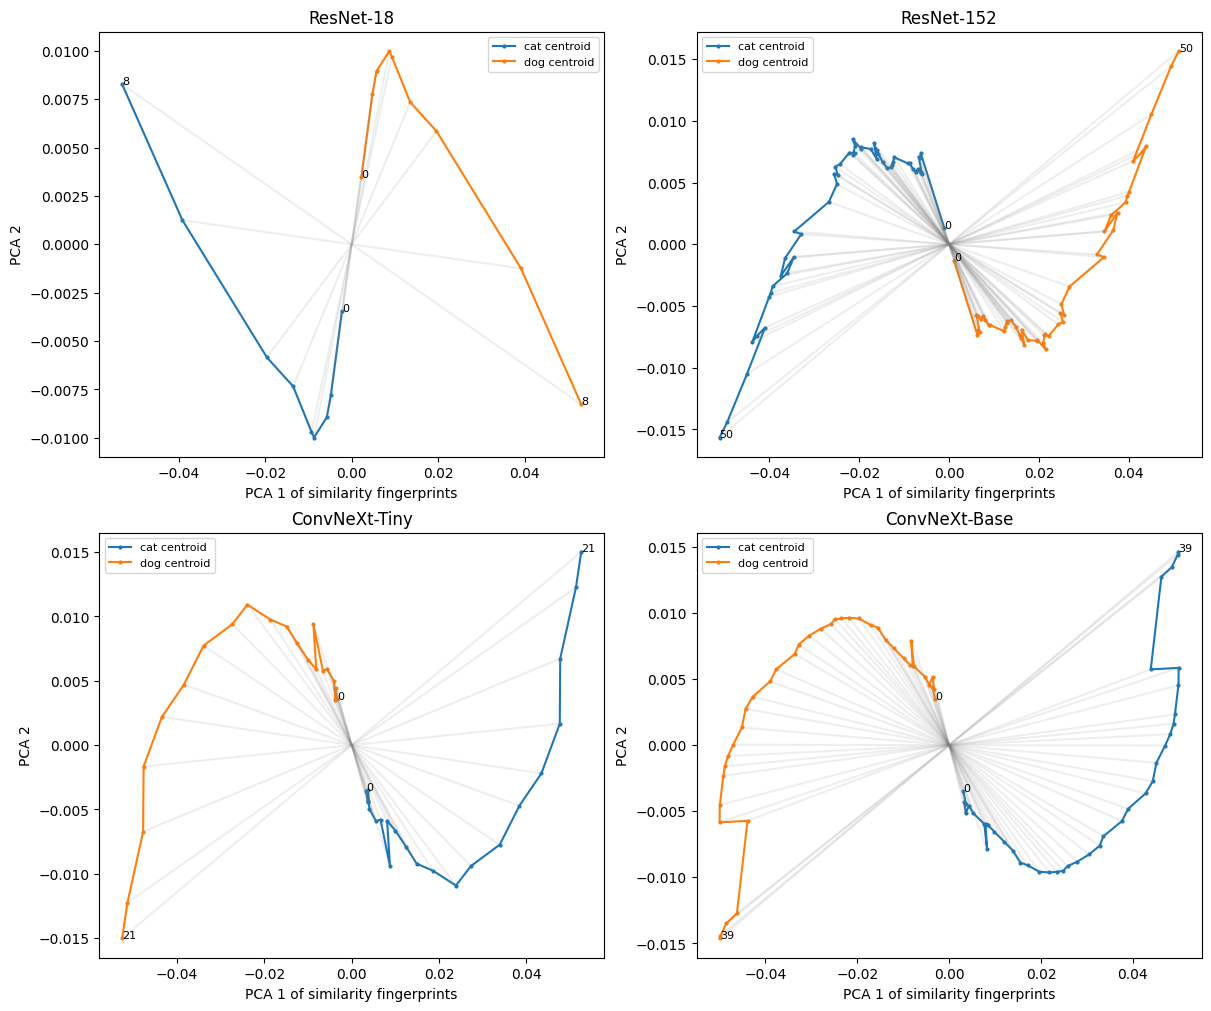


 ResNet-18


,stage,boundary,CKA_prev,S,Fisher_raw,PR,probe_mean
7,s4.b1,True,0.761,1.177,0.192,32.600,0.957
8,s4.b2,False,0.794,1.342,0.335,21.675,0.997
3,s2.b1,True,0.830,1.042,0.049,15.669,0.787
2,s1.b2,False,0.839,1.032,0.043,9.333,0.677
5,s3.b1,True,0.848,1.061,0.071,22.681,0.880
1,s1.b1,True,0.888,1.031,0.042,6.375,0.597



 ResNet-152


,stage,boundary,CKA_prev,S,Fisher_raw,PR,probe_mean
10,s1.b1,True,0.396,1.039,0.049,6.243,0.693
14,s2.b2,False,0.738,1.027,0.037,12.809,0.733
57,s4.b1,True,0.915,1.196,0.204,43.348,0.993
21,s3.b1,True,0.926,1.047,0.057,22.788,0.847
59,s4.b3,False,0.933,1.305,0.305,28.962,1.000
15,s2.b3,False,0.944,1.030,0.039,12.269,0.737



 ConvNeXt-Tiny


,stage,boundary,CKA_prev,S,Fisher_raw,PR,probe_mean
78,down3,True,0.118,1.248,0.254,31.073,0.993
68,down2,True,0.408,1.038,0.046,17.497,0.777
67,s2.b3,False,0.655,1.087,0.111,4.751,0.793
64,down1,True,0.702,1.024,0.034,7.957,0.657
75,s3.b7,False,0.715,1.146,0.098,34.010,0.953
62,s1.b2,False,0.724,1.023,0.036,7.451,0.677



 ConvNeXt-Base


,stage,boundary,CKA_prev,S,Fisher_raw,PR,probe_mean
118,down3,True,0.088,1.334,0.310,20.604,1.000
90,down2,True,0.399,1.040,0.048,16.183,0.750
89,s2.b3,False,0.698,1.074,0.098,5.741,0.770
86,down1,True,0.702,1.025,0.036,9.523,0.687
85,s1.b3,False,0.742,1.026,0.034,6.019,0.667
107,s3.b17,False,0.767,1.156,0.119,42.600,0.983


In [ ]:
fig,axs=plt.subplots(2,2,figsize=(12,10),constrained_layout=True)
for ax,(name,coords) in zip(axs.flat,trajectories.items()):
    cat,dog=coords[::2],coords[1::2]
    ax.plot(cat[:,0],cat[:,1],'-o',markersize=2,label='cat centroid')
    ax.plot(dog[:,0],dog[:,1],'-o',markersize=2,label='dog centroid')
    for i in [0,len(cat)-1]:
        ax.annotate(str(i),cat[i],fontsize=8)
        ax.annotate(str(i),dog[i],fontsize=8)
    for i in range(len(cat)):
        ax.plot([cat[i,0],dog[i,0]],[cat[i,1],dog[i,1]],color='gray',alpha=.13)
    ax.set(title=name,xlabel='PCA 1 of similarity fingerprints',ylabel='PCA 2')
    ax.legend(fontsize=8)
plt.show()

# See transitions, not merely endpoint effects.
for name,g in results.groupby('model',sort=False):
    print('\n',name)
    display(g.nsmallest(6,'CKA_prev')[['stage','boundary','CKA_prev','S','Fisher_raw','PR','probe_mean']].round(3))


## Interpretation and caveats

- **Linear CKA** compares centered sample Gram matrices and handles unequal feature widths. Large adjacent CKA means similar relational geometry on these 200 examples, not identical activations. A dip can reflect a downsampling or pooling change; it is not by itself a phase transition. Compare stage boundaries with within-stage blocks. See [Kornblith et al., ICML 2019](https://proceedings.mlr.press/v97/kornblith19a.html).
- **S** uses cosine distance after per-image L2 normalization. A rising S may accompany rising within distance; inspect both. Unit-vector Euclidean distance is related by $\|u-v\|=\sqrt{2(1-\cos	heta)}$; it is another scale of the same pairwise geometry, not an independent signal.
- **Fisher** here uses squared class-centroid separation divided by the sum of raw within-class mean squared spreads. Its raw feature norm makes it a different lens from cosine S, but class separation metrics remain correlated.
- **PR** is the participation ratio of the centered, unit-normalized sample cloud. It is an effective dimension under this estimator, not a unique intrinsic manifold dimension.
- **Trajectory** uses each image's similarity to the same ordered 200 images, then one shared PCA over all class-centroid similarity fingerprints *within each model*. This permits plotted paths when channel counts change, but coordinates describe changing relational similarity, not raw activation trajectories. 2D projection can hide changes.
- **Probe** freezes every network and fits the same regularized linear classifier on five paired 70/30 splits. Test identities match across all layers and architectures. The reported SD is descriptive; splits overlap.
- Global average pooling at every hook discards spatial information. These are block outputs, with architectural transitions marked; the horizontal coordinate counts **observations**, not equal physical depth. Cross-architecture curves cannot be treated as a controlled depth-only comparison, since weights and network designs also change.


In [ ]:
# Boundary changes and category-separation increments
changes = results.copy()
for field in ['S', 'Fisher_raw', 'PR', 'probe_mean']:
    changes['delta_' + field] = changes.groupby('model', sort=False)[field].diff()
valid = changes.dropna(subset=['CKA_prev'])
boundary_summary = (valid.groupby(['model', 'boundary'], sort=False)
                    .agg(n=('CKA_prev','size'), median_CKA=('CKA_prev','median'),
                         median_delta_S=('delta_S','median'), mean_delta_S=('delta_S','mean'))
                    .reset_index())
display(boundary_summary.round(3))
for name, g in valid.groupby('model', sort=False):
    print(name, 'largest positive S increments')
    display(g.nlargest(5, 'delta_S')[['stage','boundary','CKA_prev','delta_S','S','delta_Fisher_raw','delta_PR','probe_mean']].round(3))
print('Boundary is the first block of a ResNet stage, or a ConvNeXt downsample / first stage block. Consecutive measurements are not equal-depth steps.')


,model,boundary,n,median_CKA,median_delta_S,mean_delta_S
0,ResNet-18,True,4,0.839,0.018,0.035
1,ResNet-18,False,4,0.867,0.011,0.046
2,ResNet-152,True,4,0.921,0.019,0.017
3,ResNet-152,False,46,0.990,0.001,0.005
4,ConvNeXt-Tiny,True,7,0.843,0.003,0.000
5,ConvNeXt-Tiny,False,14,0.883,0.018,0.022
6,ConvNeXt-Base,True,7,0.851,0.001,0.001
7,ConvNeXt-Base,False,32,0.984,0.008,0.010


ResNet-18 largest positive S increments


,stage,boundary,CKA_prev,delta_S,S,delta_Fisher_raw,delta_PR,probe_mean
8,s4.b2,False,0.794,0.165,1.342,0.143,-10.925,0.997
7,s4.b1,True,0.761,0.096,1.177,0.103,2.644,0.957
5,s3.b1,True,0.848,0.021,1.061,0.025,2.208,0.880
6,s3.b2,False,0.895,0.021,1.082,0.018,7.274,0.920
1,s1.b1,True,0.888,0.015,1.031,0.005,3.118,0.597


ResNet-152 largest positive S increments


,stage,boundary,CKA_prev,delta_S,S,delta_Fisher_raw,delta_PR,probe_mean
58,s4.b2,False,0.945,0.067,1.263,0.065,-9.436,1.000
45,s3.b25,False,0.978,0.046,1.145,0.047,-3.450,0.977
59,s4.b3,False,0.933,0.043,1.305,0.036,-4.950,1.000
10,s1.b1,True,0.396,0.035,1.039,0.028,4.542,0.693
54,s3.b34,False,0.977,0.034,1.202,0.034,-2.337,1.000


ConvNeXt-Tiny largest positive S increments


,stage,boundary,CKA_prev,delta_S,S,delta_Fisher_raw,delta_PR,probe_mean
80,s4.b2,False,0.897,0.068,1.309,0.061,-7.047,1.000
67,s2.b3,False,0.655,0.060,1.087,0.040,-13.652,0.793
78,down3,True,0.118,0.046,1.248,0.208,-3.460,0.993
77,s3.b9,False,0.876,0.033,1.202,0.006,-1.164,0.983
75,s3.b7,False,0.715,0.033,1.146,-0.023,0.450,0.953


ConvNeXt-Base largest positive S increments


,stage,boundary,CKA_prev,delta_S,S,delta_Fisher_raw,delta_PR,probe_mean
118,down3,True,0.088,0.040,1.334,0.266,0.696,1.000
89,s2.b3,False,0.698,0.040,1.074,0.042,-13.107,0.770
108,s3.b18,False,0.983,0.027,1.184,0.028,-3.187,0.993
115,s3.b25,False,0.980,0.024,1.279,-0.005,-3.140,1.000
116,s3.b26,False,0.971,0.024,1.303,-0.019,-3.098,1.000


Boundary is the first block of a ResNet stage, or a ConvNeXt downsample / first stage block. Consecutive measurements are not equal-depth steps.


In [ ]:
# Full per-block measurements for later analysis
results.to_csv('block_geometry_metrics.csv', index=False)
print('Saved', len(results), 'rows to block_geometry_metrics.csv')

Saved 122 rows to block_geometry_metrics.csv
